# **Machine Learning based Crop Recommendation**

**Story**: A farmer wants to seed a crop in his farmland. And very first step is decide the crop to seed.
This enables him to decide, *which crop* is best for the soil 🌳.

**Section** 1: Import Libraries

**Section** 2: Load the Dataset

**Section** 3: Explore the Data

**Section** 4: Prepare Data for Model

**Section** 5: Machine Learning model 1: KNN

**Section** 6: Machine Learning model 2:DT

**Section** 7: ConMachine Learning model 3:RF

**Section** 8: Compare results of all models

**Section** 9: Final summary


# Section 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Section 2: Load the Dataset 📂  
We load the file Crop_recommendation.csv directly using pandas.

**Input** Features of Data
*   N - ratio of Nitrogen content in soil
*   P - ratio of Phosphorous content in soil
*   K - ratio of Potassium content in soil
*   temperature - temperature in degree Celsius
*   humidity - relative humidity in %
*   ph - ph value of the soil
*   rainfall - rainfall in mm


**Output**
*   Label of crop


In [2]:
df=pd.read_csv('/content/Crop_recommendation.csv')

In [3]:
dataset=df

In [4]:
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [5]:
print("File loaded successfully!")
print("Total rows    :", len(df))
print("Total columns :", len(df.columns))
print()
print("Column names:")
print(list(df.columns))


File loaded successfully!
Total rows    : 2200
Total columns : 8

Column names:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [6]:
df.head(10)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


# Section 3: Explore the *Data*

In [7]:
# Basic info — data types and missing values
print("Data types of each column:")
print(df.dtypes)
print()
print("Missing values in each column:")
print(df.isnull().sum())


Data types of each column:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

Missing values in each column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [8]:
# Summary statistics
df.describe().round(1)

,N,P,K,temperature,humidity,ph,rainfall
count,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0
mean,50.6,53.4,48.1,25.6,71.5,6.5,103.5
std,36.9,33.0,50.6,5.1,22.3,0.8,55.0
min,0.0,5.0,5.0,8.8,14.3,3.5,20.2
25%,21.0,28.0,20.0,22.8,60.3,6.0,64.6
50%,37.0,51.0,32.0,25.6,80.5,6.4,94.9
75%,84.2,68.0,49.0,28.6,89.9,6.9,124.3
max,140.0,145.0,205.0,43.7,100.0,9.9,298.6


In [9]:
unique_values = df['label'].unique()
unique_values

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

# Section 04: Prepare Data for Models


In [10]:
#dataset = dataset.replace({"label":  {'rice':1, 'maize':2, 'chickpea':3, 'kidneybeans':4, 'pigeonpeas':5,'mothbeans':6, 'mungbean':7, 'blackgram':8, 'lentil':9, 'pomegranate':10,'banana':11, 'mango':12, 'grapes':13, 'watermelon':14, 'muskmelon':15, 'apple':16,   'orange':17, 'papaya':18, 'coconut':19, 'cotton':20, 'jute':21, 'coffee':22}})

In [11]:
X = dataset.iloc[:,:-1]
y = dataset.iloc[:, -1].values

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)


# Section 5 Machine Learning model:KNN

# KNN

In [13]:
from sklearn.neighbors import KNeighborsClassifier
classifier= KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2 )
classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [14]:
y_pred = classifier.predict(X_test)

In [15]:
results_knn = pd.DataFrame(X_test, columns=X.columns)
results_knn['True_Label'] = y_test
results_knn['Predicted_Label'] = y_pred
display(results_knn.head(20))

,N,P,K,temperature,humidity,ph,rainfall,True_Label,Predicted_Label
1320,105,14,50,26.214884,87.688398,6.419052,59.655908,watermelon,watermelon
1367,91,12,46,24.644585,85.499382,6.343943,48.312190,watermelon,watermelon
1291,14,121,203,9.724458,83.747656,6.158689,74.464111,grapes,grapes
264,52,73,79,17.257695,18.749440,7.840339,94.002872,chickpea,chickpea
728,32,66,17,34.946616,65.267740,7.162358,70.141514,blackgram,blackgram
70,61,52,41,24.976695,83.891805,6.880431,204.800185,rice,jute
565,11,41,19,26.859113,41.814208,5.131779,44.138271,mothbeans,mothbeans
399,22,60,24,18.782263,20.247683,5.630665,104.257072,kidneybeans,kidneybeans
1446,106,20,51,29.730197,90.970157,6.342573,20.490356,muskmelon,muskmelon
1063,93,83,46,29.382540,83.504237,5.765309,109.248665,banana,banana


### KNN Model Evaluation

In [16]:
print("KNN Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

KNN Model Evaluation:
Accuracy: 0.9781818181818182

Confusion Matrix:
 [[24  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 24  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 28  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 24  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 24  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 25  0  0  0  0  0  0  0  0  0  0  0  3  0]
 [ 0  0  0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 24  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 

#### KNN Confusion Matrix Heatmap

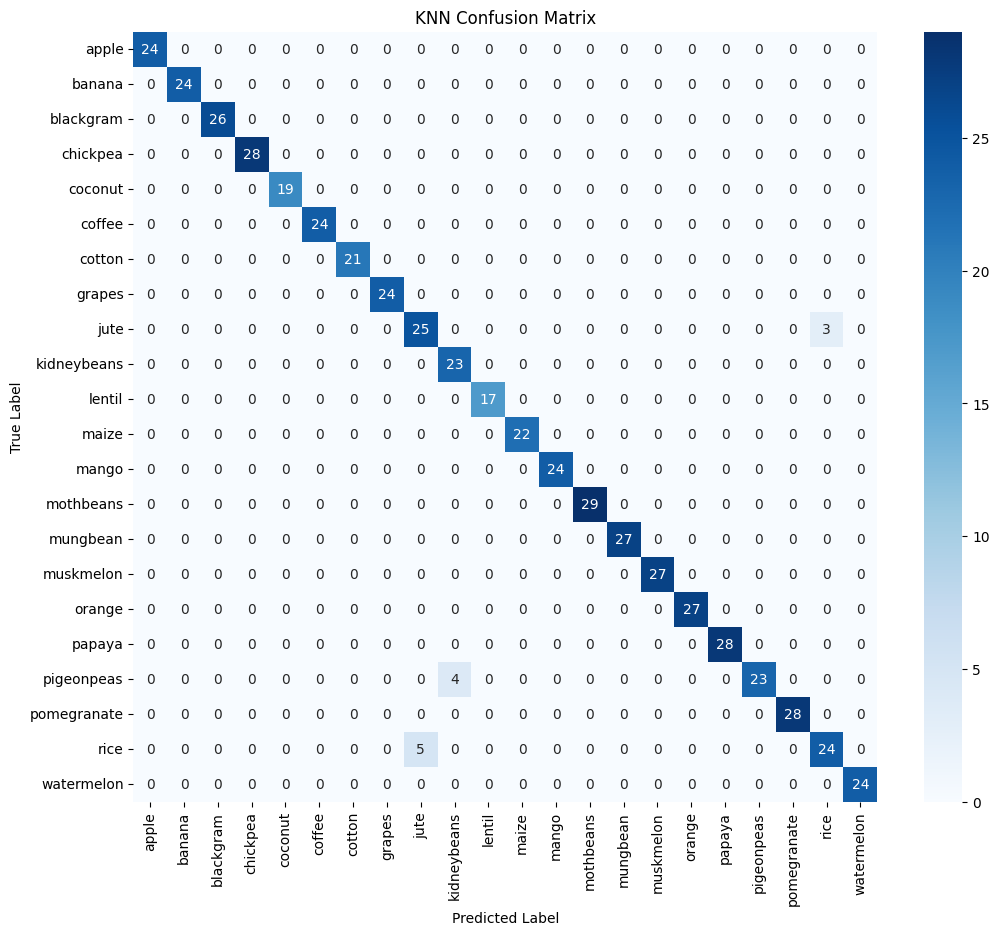

In [17]:
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=classifier.classes_, yticklabels=classifier.classes_)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Section 6 Machine Learning model:DT

# Decision Tree

In [18]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=0)

In [19]:
clf.fit(X_train,y_train)

DecisionTreeClassifier(random_state=0)

In [20]:
y_pred = clf.predict(X_test)

In [21]:
y_pred

array(['watermelon', 'watermelon', 'grapes', 'chickpea', 'blackgram',
       'rice', 'mothbeans', 'kidneybeans', 'muskmelon', 'banana',
       'mothbeans', 'coffee', 'lentil', 'mungbean', 'mango', 'apple',
       'coffee', 'lentil', 'coffee', 'mango', 'coconut', 'blackgram',
       'kidneybeans', 'jute', 'cotton', 'coffee', 'lentil', 'orange',
       'mothbeans', 'chickpea', 'pomegranate', 'rice', 'maize',
       'muskmelon', 'coconut', 'cotton', 'mango', 'mango', 'watermelon',
       'mothbeans', 'maize', 'blackgram', 'pigeonpeas', 'watermelon',
       'pigeonpeas', 'mungbean', 'kidneybeans', 'kidneybeans', 'cotton',
       'mungbean', 'mothbeans', 'blackgram', 'apple', 'muskmelon',
       'pigeonpeas', 'banana', 'papaya', 'mango', 'lentil', 'cotton',
       'orange', 'mungbean', 'watermelon', 'rice', 'muskmelon', 'apple',
       'grapes', 'coffee', 'apple', 'orange', 'coconut', 'pomegranate',
       'kidneybeans', 'maize', 'grapes', 'mothbeans', 'chickpea', 'maize',
       'jute', 'm

In [22]:
len(y_pred)

550

### Decision Tree Model Evaluation

In [23]:
print("Decision Tree Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Decision Tree Model Evaluation:
Accuracy: 0.9890909090909091

Confusion Matrix:
 [[24  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 24  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 25  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0 28  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 24  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 24  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 25  0  0  0  0  0  0  0  0  2  0  0  1  0]
 [ 0  0  0  2  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 24  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0

#### Decision Tree Visualization

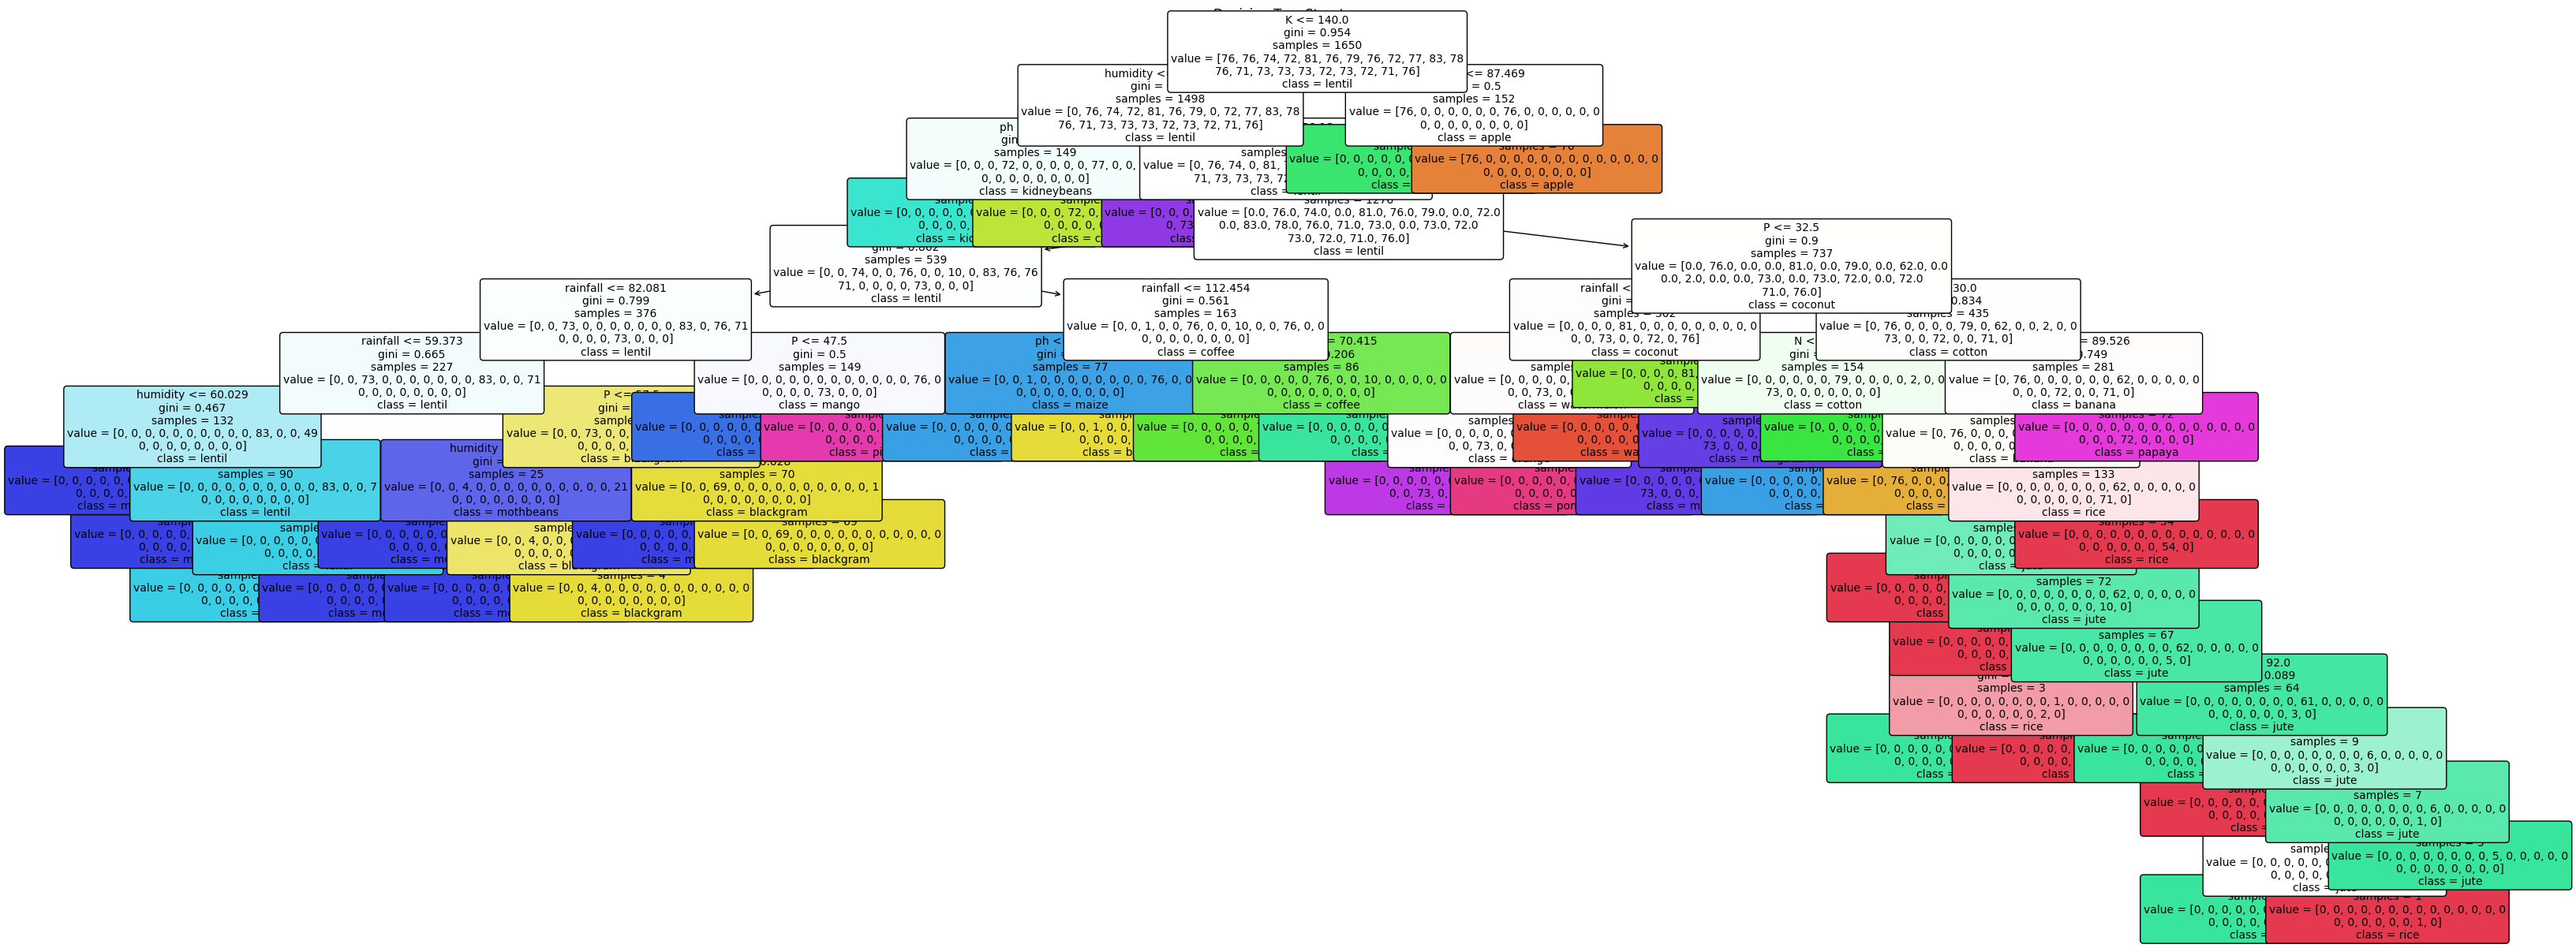

In [24]:
plt.figure(figsize=(40, 15))
plot_tree(clf, feature_names=X.columns, class_names=clf.classes_, filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Structure')
plt.show()

# Section 7 Machine Learning model:RF

# Random Forest

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
rfc = RandomForestClassifier()

In [27]:
rfc.fit(X_train,y_train)

RandomForestClassifier()

y_pred = rfc.predict(X_test)

### Random Forest Model Evaluation

In [28]:
y_pred_rf = rfc.predict(X_test)
print("Random Forest Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Model Evaluation:
Accuracy: 0.9981818181818182

Confusion Matrix:
 [[24  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 24  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 28  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 24  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 24  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 28  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 24  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0

#### Random Forest Feature Importance

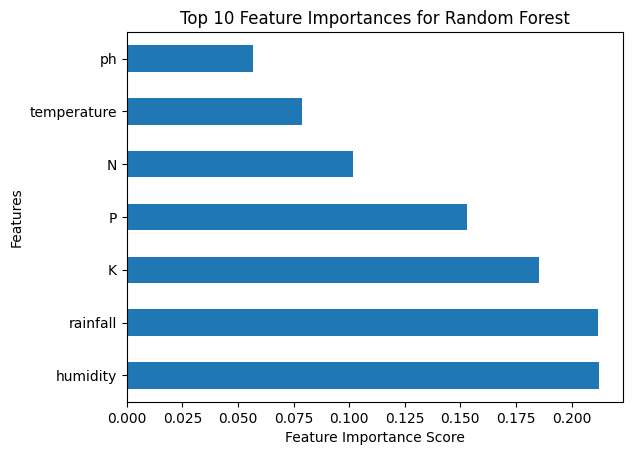

In [29]:
feature_importances = pd.Series(rfc.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances for Random Forest')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.show()

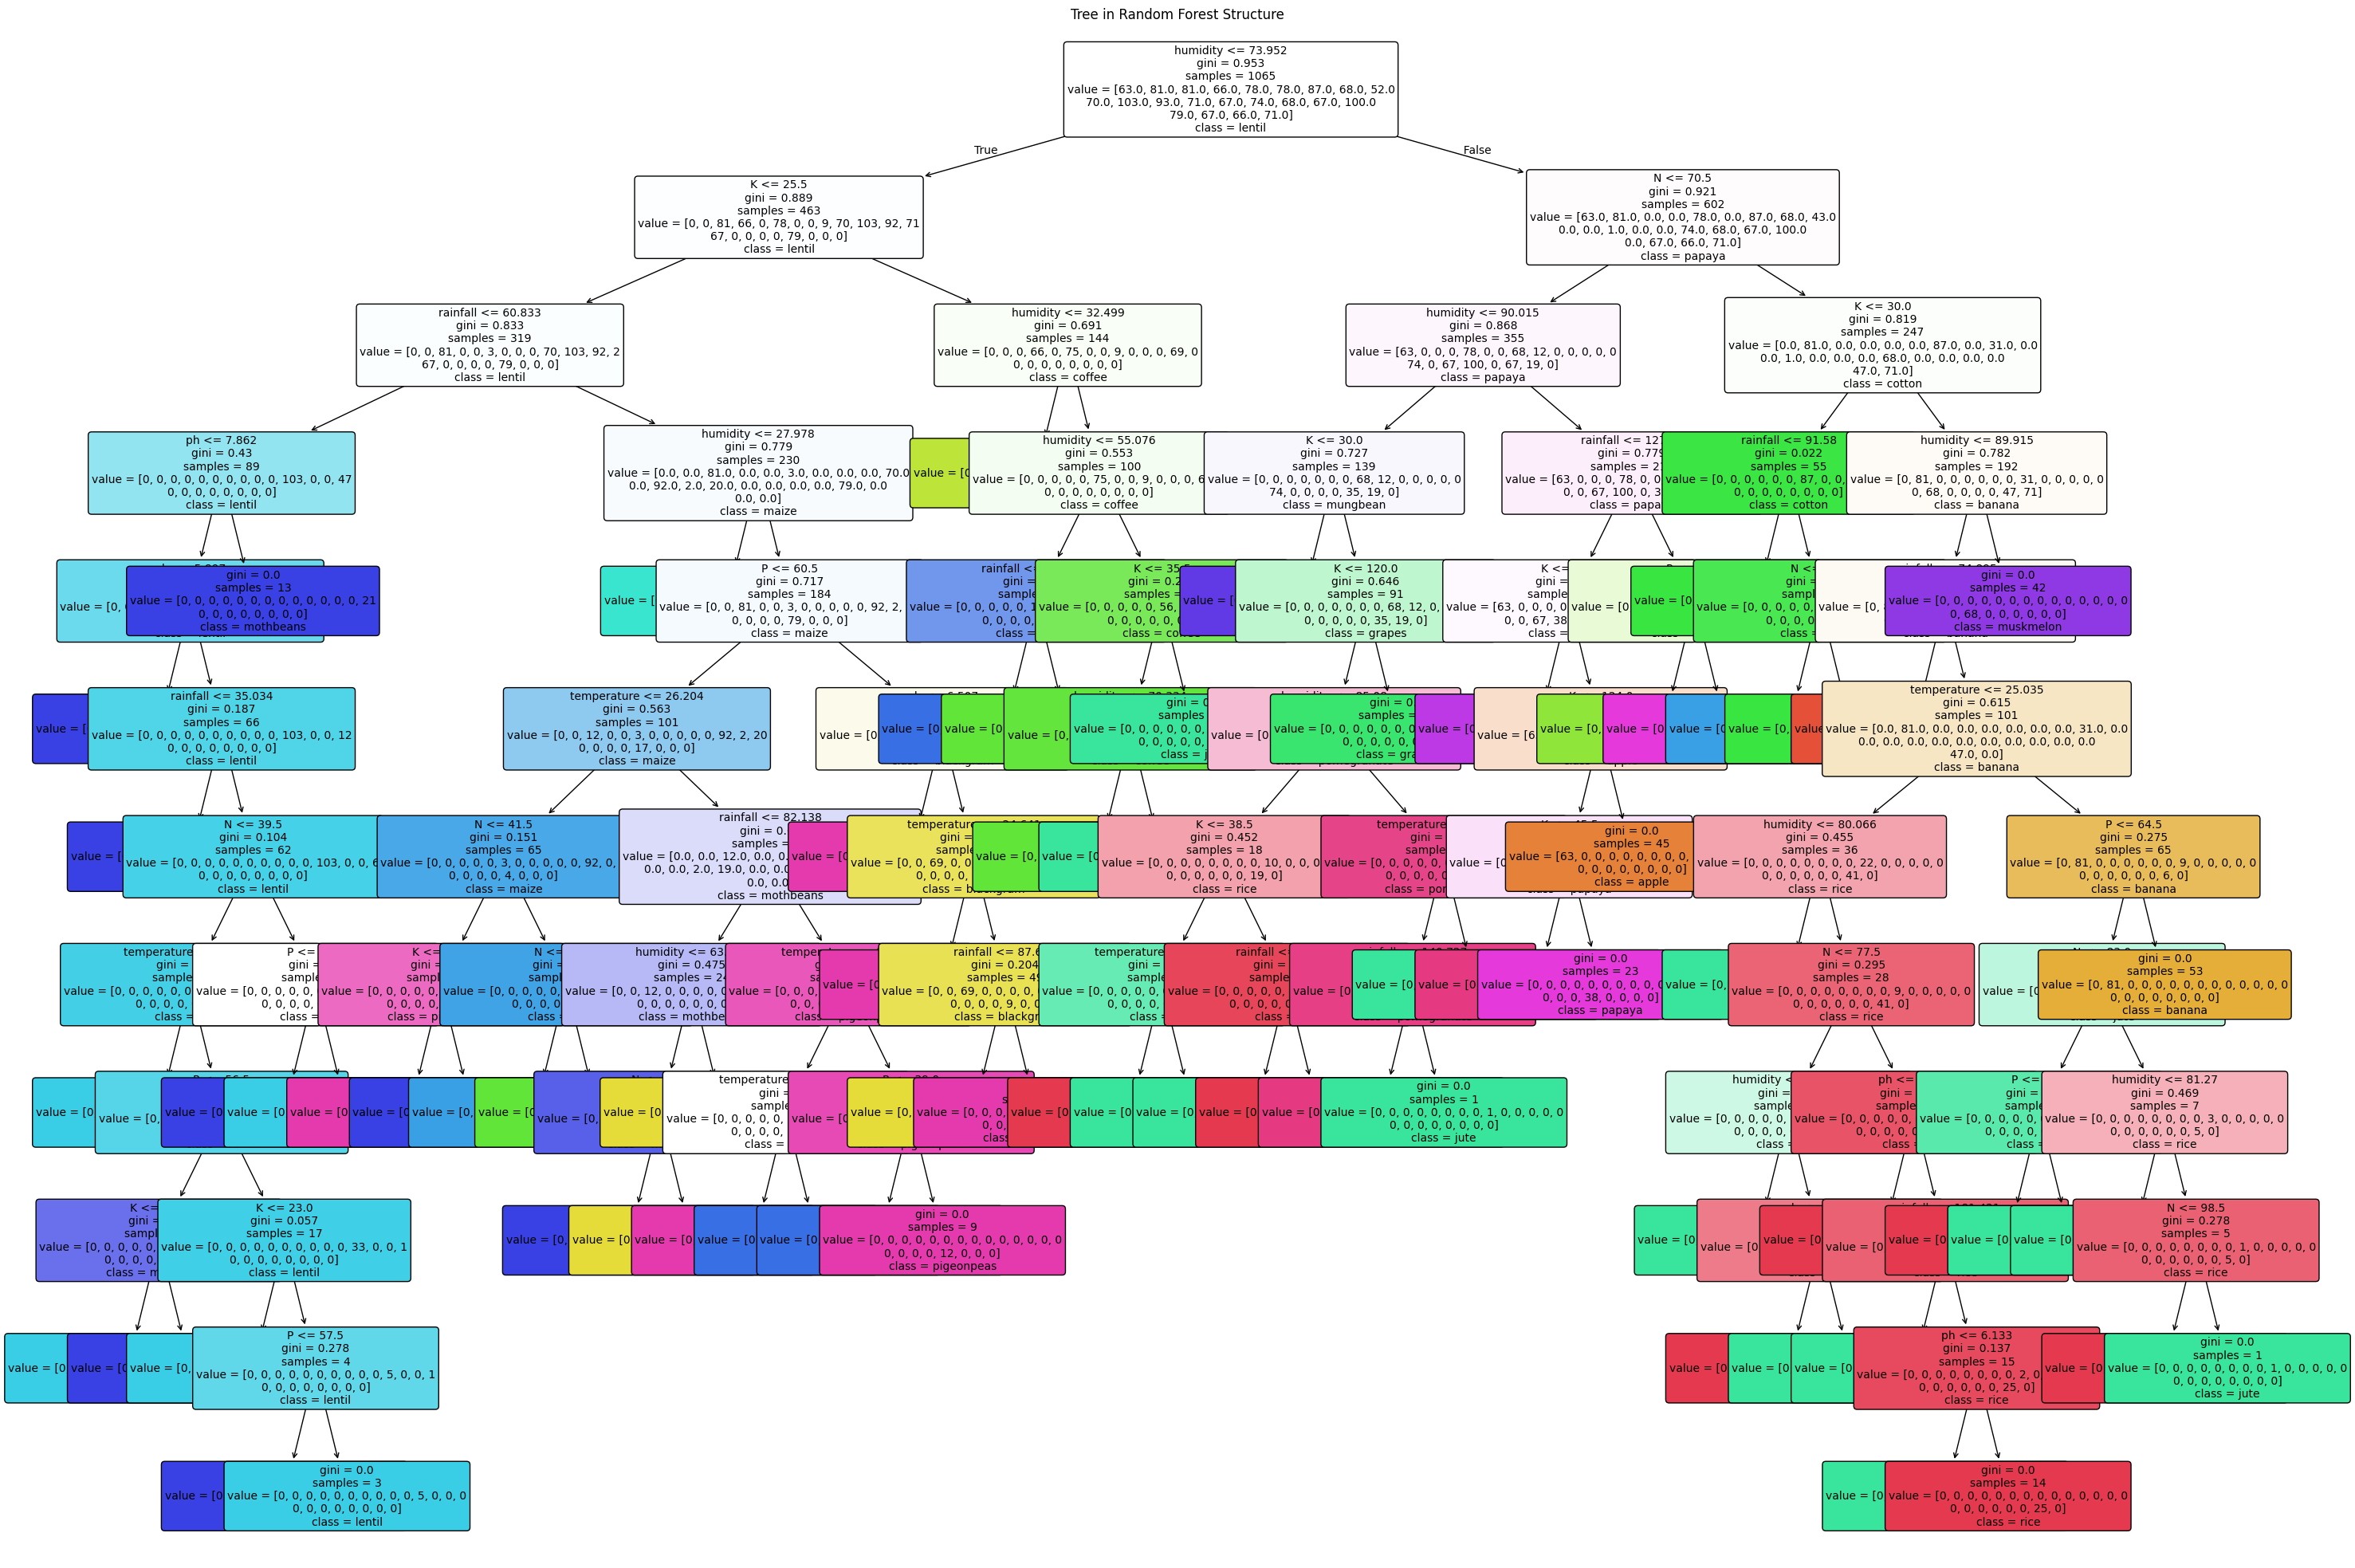

In [30]:
plt.figure(figsize=(35, 25))
# Access the first estimator (decision tree) from the Random Forest
plot_tree(rfc.estimators_[0], feature_names=X.columns, class_names=rfc.classes_, filled=True, rounded=True, fontsize=10)
plt.title('Tree in Random Forest Structure')
plt.show()

# Section 8:Compare the results of all models

In [31]:
results = {
    'Model': ['KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [0.97818, 0.98909, 0.99818],
    'Precision (macro avg)': [0.98, 0.99, 1.00],
    'Recall (macro avg)': [0.98, 0.99, 1.00]
}
results_df = pd.DataFrame(results)
display(results_df)

,Model,Accuracy,Precision (macro avg),Recall (macro avg)
0,KNN,0.97818,0.98,0.98
1,Decision Tree,0.98909,0.99,0.99
2,Random Forest,0.99818,1.00,1.00


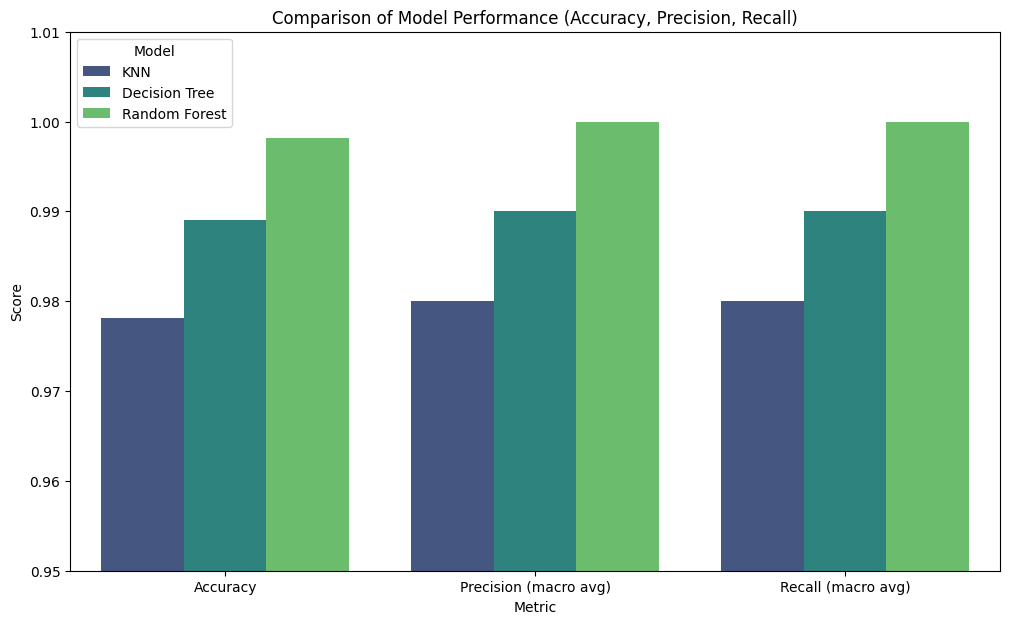

In [32]:
metrics_df = results_df.set_index('Model').stack().reset_index()
metrics_df.columns = ['Model', 'Metric', 'Score']

plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_df, palette='viridis')
plt.title('Comparison of Model Performance (Accuracy, Precision, Recall)')
plt.ylabel('Score')
plt.ylim(0.95, 1.01) # Set y-axis limit to better visualize differences
plt.show()

# Section 9: Final summary

**1. Setup and Data Loading (Sections 1 & 2):**
* The necessary libraries for data manipulation, visualization, and machine learning (pandas, matplotlib, seaborn, sklearn) were imported.
* The Crop_recommendation.csv dataset was loaded into a pandas DataFrame. The dataset contains input features like N, P, K, temperature, humidity, pH, and rainfall, with 'label' as the target variable for crop recommendation.

**2. Data Exploration (Section 3):**
* Basic information about the dataset, including data types and the absence of missing values, was checked. * Summary statistics provided insights into the distribution of numerical features.
* The unique crop labels in the dataset were identified.

**3. Data Preparation for Modeling (Section 4):**
* The dataset was split into features (X) and the target variable (y).
* The data was then further divided into training and testing sets using train_test_split, allocating 75% for training and 25% for testing.

**4. Machine Learning Models and Evaluation (Sections 5, 6 & 7):**
* K-Nearest Neighbors (KNN): * A KNN classifier was trained with n_neighbors=5. * The model achieved an accuracy of 0.97818. * Its performance was evaluated using a confusion matrix, classification report, and a confusion matrix heatmap for visualization.
* Decision Tree (DT): * A Decision Tree classifier was trained. * This model achieved an accuracy of 0.98909. * Evaluation included a confusion matrix, classification report, and a detailed visualization of the decision tree structure, with increased figsize and fontsize for improved readability.
* Random Forest (RF): * A Random Forest classifier was trained. * This model demonstrated the highest performance with an accuracy of 0.99818. * Its evaluation included a confusion matrix, classification report, a feature importance bar plot, and a visualization of the first individual tree within the forest, also with adjusted figsize and fontsize for clarity.

**5. Model Comparison (Section 8):**
* A table was generated to compare the Accuracy, Precision (macro avg), and Recall (macro avg) across all three models.
* A bar chart was created to visually represent these performance metrics, confirming the Random Forest model as the best performer.